1. Load the backtest

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

backtest = pd.read_csv(
    "../data/processed/backtest.csv",
    index_col=0,
    parse_dates=True
)

strategy = pd.read_csv(
    "../data/processed/strategy_signals.csv",
    index_col=0,
    parse_dates=True
)

backtest.head()

,position,gross_return,transaction_cost,slippage,net_return,gross_equity,net_equity
Date,,,,,,,
2018-01-02,NaN,0.0,NaN,NaN,NaN,1.0,NaN
2018-01-03,NaN,0.0,NaN,NaN,NaN,1.0,NaN
2018-01-04,NaN,0.0,NaN,NaN,NaN,1.0,NaN
2018-01-05,NaN,0.0,NaN,NaN,NaN,1.0,NaN
2018-01-08,NaN,0.0,NaN,NaN,NaN,1.0,NaN


2. Identify individual trades 

In [26]:
position = strategy["position"]

entries = position.ne(position.shift(1)) & position.ne(0)
exits = position.eq(0) & position.shift(1).ne(0)

print("Entries:", entries.sum())
print("Exits:", exits.sum())

Entries: 34
Exits: 34


In [27]:
# trade table 

trades = []

entry_date = None
entry_position = None

for date, pos in position.items():

    previous = position.shift(1).loc[date]

    # Entry
    if previous == 0 and pos != 0:
        entry_date = date
        entry_position = pos

    # Exit
    elif previous != 0 and pos == 0 and entry_date is not None:

        trade_returns = backtest.loc[
            entry_date:date,
            "net_return"
        ]

        trade_return = (
            (1 + trade_returns).prod() - 1
        )

        trades.append({
            "entry_date": entry_date,
            "exit_date": date,
            "direction": (
                "Long Spread"
                if entry_position == 1
                else "Short Spread"
            ),
            "return": trade_return,
            "holding_days": (
                date - entry_date
            ).days
        })

        entry_date = None
        entry_position = None

trades = pd.DataFrame(trades)

trades.head()

,entry_date,exit_date,direction,return,holding_days
0,2018-04-11,2018-06-12,Short Spread,-0.021257,62
1,2018-07-19,2018-07-30,Long Spread,0.017514,11
2,2018-09-27,2018-10-24,Short Spread,-0.001668,27
3,2018-12-19,2018-12-28,Short Spread,0.006903,9
4,2019-01-14,2019-01-31,Short Spread,0.010969,17


3. Analyze the trade 

In [28]:
print("Number of trades:", len(trades))

print(
    f"Average trade return: "
    f"{trades['return'].mean():.2%}"
)

print(
    f"Median trade return: "
    f"{trades['return'].median():.2%}"
)

print(
    f"Winning trades: "
    f"{(trades['return'] > 0).sum()}"
)

print(
    f"Losing trades: "
    f"{(trades['return'] < 0).sum()}"
)

Number of trades: 33
Average trade return: -0.48%
Median trade return: 0.69%
Winning trades: 18
Losing trades: 15


In [29]:
# Win rate 

trade_win_rate = (
    trades["return"] > 0
).mean()

print(f"Trade win rate: {trade_win_rate:.2%}")

Trade win rate: 54.55%


4. Holding period 

In [30]:
print(
    f"Average holding period: "
    f"{trades['holding_days'].mean():.1f} days"
)

print(
    f"Median holding period: "
    f"{trades['holding_days'].median():.1f} days"
)

Average holding period: 43.7 days
Median holding period: 28.0 days


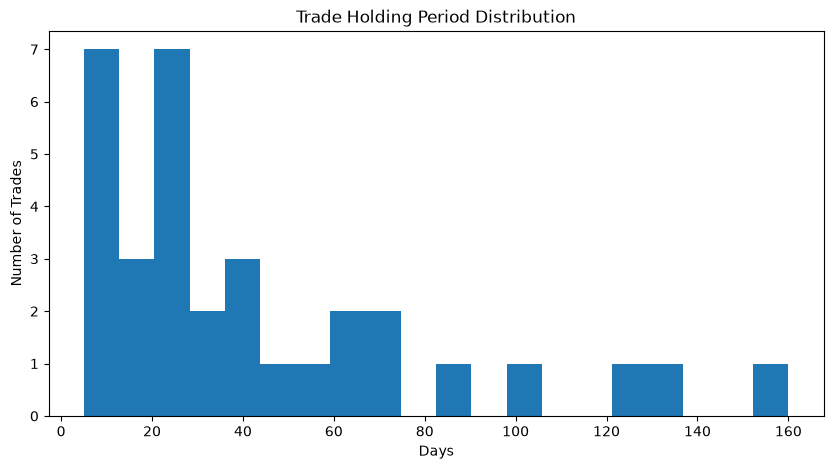

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(
    trades["holding_days"],
    bins=20
)

plt.title("Trade Holding Period Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Trades")

plt.show()

5. P/L distribution

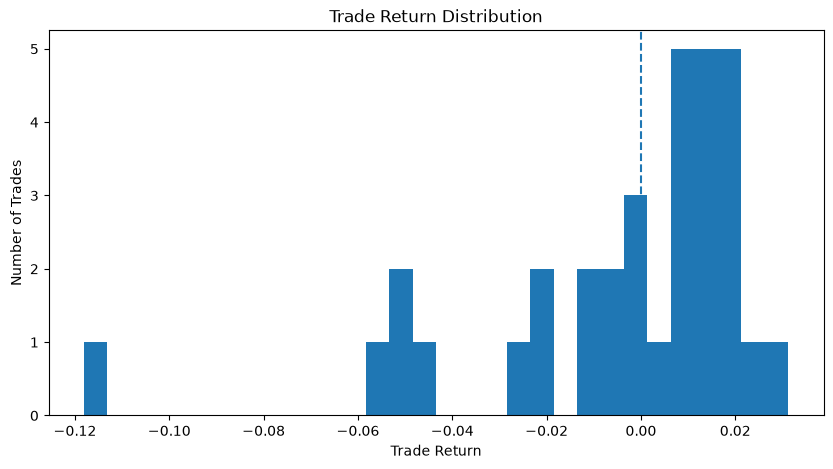

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    trades["return"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Trade Return Distribution")
plt.xlabel("Trade Return")
plt.ylabel("Number of Trades")

plt.show()

6. Robustness : test different parameters of entry threshold, exit threshold, rolling windows 
// Really the core of the project 

In [33]:
def generate_positions(
    z_score,
    entry_threshold,
    exit_threshold
):

    position = pd.Series(
        0,
        index=z_score.index
    )

    current_position = 0

    for date in z_score.index:

        z = z_score.loc[date]

        if current_position == 0:

            if z < -entry_threshold:
                current_position = 1

            elif z > entry_threshold:
                current_position = -1

        elif current_position == 1:

            if z > -exit_threshold:
                current_position = 0

        elif current_position == -1:

            if z < exit_threshold:
                current_position = 0

        position.loc[date] = current_position

    return position

7. Test multiple entry thresholds 

In [34]:
prices = pd.read_csv(
    "../data/processed/clean_prices.csv",
    index_col=0,
    parse_dates=True
).dropna()

log_prices = np.log(prices)

import statsmodels.api as sm

X = sm.add_constant(log_prices["PEP"])
model = sm.OLS(log_prices["KO"], X).fit()

beta = model.params["PEP"]

spread = (
    log_prices["KO"]
    - beta * log_prices["PEP"]
)

In [35]:
# Create Z-score

In [36]:
window = 60

z_score = (
    spread - spread.rolling(window).mean()
) / spread.rolling(window).std()

z_score = z_score.dropna()

In [38]:
# Trouble shoot : Calculate daily returns
returns = prices[["KO", "PEP"]].pct_change().dropna()

returns.head()

results = []

for threshold in [1.5, 2.0, 2.5, 3.0]:

    position_test = generate_positions(
        z_score,
        entry_threshold=threshold,
        exit_threshold=0.5
    )

    strategy_ret = (
        position_test.shift(1)
        * (
            returns["KO"]
            - beta * returns["PEP"]
        )
    ).fillna(0)

    equity = (
        1 + strategy_ret
    ).cumprod()

    total_return = equity.iloc[-1] - 1

    sharpe = (
        strategy_ret.mean()
        / strategy_ret.std()
    ) * np.sqrt(252)

    results.append({
        "entry_threshold": threshold,
        "total_return": total_return,
        "sharpe": sharpe,
        "trades": (
            position_test.diff().abs() > 0
        ).sum()
    })

robustness = pd.DataFrame(results)

robustness

,entry_threshold,total_return,sharpe,trades
0,1.5,-0.416611,-0.421340,95
1,2.0,-0.404879,-0.450993,67
2,2.5,-0.412817,-0.543642,41
3,3.0,-0.463352,-0.710084,27


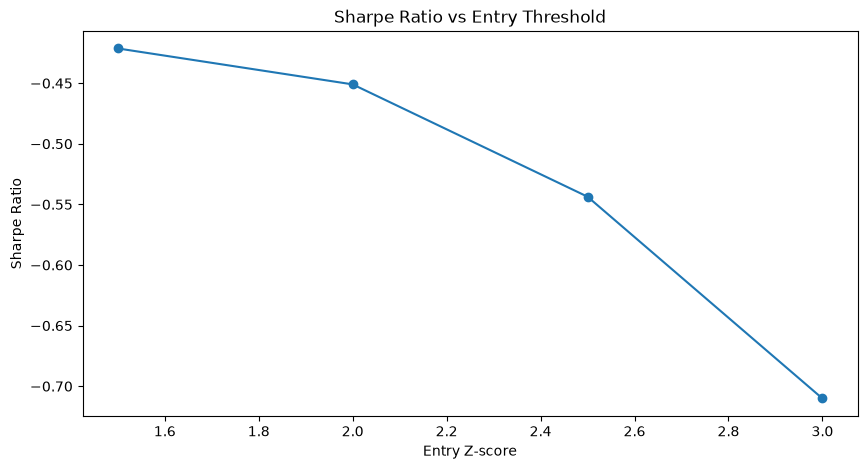

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    robustness["entry_threshold"],
    robustness["sharpe"],
    marker="o"
)

plt.title("Sharpe Ratio vs Entry Threshold")
plt.xlabel("Entry Z-score")
plt.ylabel("Sharpe Ratio")

plt.show()

Since our Sharpe Ratio changes under a certain rule, the results may not be parameter-sensitive or overfitting. 

8. Test the rolling window too 

In [40]:
windows = [30, 60, 90, 120, 180]

window_results = []

for window in windows:

    z = (
        spread - spread.rolling(window).mean()
    ) / spread.rolling(window).std()

    z = z.dropna()

    position_test = generate_positions(
        z,
        entry_threshold=2.0,
        exit_threshold=0.5
    )

    strategy_ret = (
        position_test.shift(1)
        * (
            returns["KO"]
            - beta * returns["PEP"]
        )
    ).fillna(0)

    sharpe = (
        strategy_ret.mean()
        / strategy_ret.std()
    ) * np.sqrt(252)

    window_results.append({
        "window": window,
        "sharpe": sharpe
    })

window_results = pd.DataFrame(window_results)

window_results

,window,sharpe
0,30,-0.341022
1,60,-0.450993
2,90,-0.473260
3,120,-0.368182
4,180,-0.322918


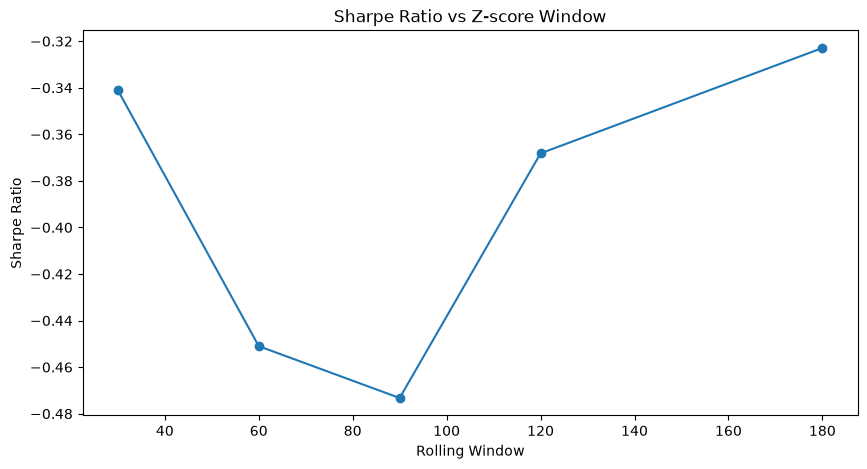

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    window_results["window"],
    window_results["sharpe"],
    marker="o"
)

plt.title("Sharpe Ratio vs Z-score Window")
plt.xlabel("Rolling Window")
plt.ylabel("Sharpe Ratio")

plt.show()

!! Rolling window may be parameter sensitive. But maybe less likely to be overfitting considering the previous test. !! 

10. Save

In [42]:
robustness.to_csv(
    "data/processed/threshold_robustness.csv",
    index=False
)

window_results.to_csv(
    "data/processed/window_robustness.csv",
    index=False
)

trades.to_csv(
    "data/processed/trades.csv",
    index=False
)

print("Robustness analysis saved.")

Robustness analysis saved.
